In [1]:
import os
import time
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import label_binarize

In [2]:
DATA_DIR = "/kaggle/input/datasets/lfreedom2750/mcvsld-split-version/skin_lesion_split_v2"

BATCH_SIZE = 64
IMAGE_SIZE = 224
NUM_WORKERS = 2

# Đây là số epoch tối đa.
# Early stopping sẽ tự dừng nếu model không còn tốt lên.
MAX_EPOCHS = 50

SAVE_DIR = Path("experiments/vgg16_optimizer_search")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
common_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=common_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=common_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=common_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

CLASS_NAMES = train_dataset.classes
CLASS_TO_IDX = train_dataset.class_to_idx
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Class to index:", CLASS_TO_IDX)
print("Num classes:", NUM_CLASSES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
Class to index: {'Chickenpox': 0, 'Cowpox': 1, 'HFMD': 2, 'Healthy': 3, 'Measles': 4, 'Monkeypox': 5}
Num classes: 6
Train samples: 602
Val samples: 73
Test samples: 80


In [5]:
def count_per_class(dataset):
    counts = {}

    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] = counts.get(class_name, 0) + 1

    return counts


train_counts = count_per_class(train_dataset)
val_counts = count_per_class(val_dataset)
test_counts = count_per_class(test_dataset)

stats_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "val": pd.Series(val_counts),
    "test": pd.Series(test_counts)
}).fillna(0).astype(int)

stats_df["total"] = stats_df.sum(axis=1)

display(stats_df)

,train,val,test,total
Chickenpox,60,7,8,75
Cowpox,52,6,8,66
HFMD,128,16,17,161
Healthy,91,11,12,114
Measles,44,5,6,55
Monkeypox,227,28,29,284


In [6]:
from torchvision.models import VGG16_Weights

def create_model(num_classes):
    weights = VGG16_Weights.IMAGENET1K_V1
    model = models.vgg16(weights=weights)

    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)

    return model

In [7]:
def format_epoch_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60

    if minutes > 0:
        return f"{minutes}m {secs:.0f}s"

    return f"{secs:.0f}s"


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def compute_specificity_multiclass(conf_matrix):
    specificities = []

    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]
        fn = conf_matrix[i, :].sum() - tp
        fp = conf_matrix[:, i].sum() - tp
        tn = conf_matrix.sum() - (tp + fn + fp)

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(specificity)

    return float(np.mean(specificities)), specificities


def evaluate_model(model, loader, criterion, device, num_classes):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            running_loss += loss.item() * images.size(0)
            total_samples += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    avg_loss = running_loss / total_samples

    cm = confusion_matrix(y_true, y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    specificity_macro, specificity_per_class = compute_specificity_multiclass(cm)

    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
        roc_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        roc_auc = None

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "sensitivity_macro": recall,
        "specificity_macro": specificity_macro,
        "specificity_per_class": specificity_per_class,
        "mcc": mcc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [8]:
def create_optimizer(model, optimizer_name, lr):

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "AdamW":

        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9
        )

    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizer

In [9]:
COMMON_LR = 1e-4

experiment_configs = [
    {
        "optimizer": "Adam",
        "lr": COMMON_LR
    },
    {
        "optimizer": "AdamW",
        "lr": COMMON_LR
    },
    {
        "optimizer": "SGD",
        "lr": COMMON_LR
    }
]

experiment_configs

[{'optimizer': 'Adam', 'lr': 0.0001},
 {'optimizer': 'AdamW', 'lr': 0.0001},
 {'optimizer': 'SGD', 'lr': 0.0001}]

In [10]:
criterion = nn.CrossEntropyLoss()

EARLY_STOPPING_PATIENCE = 7
LR_PATIENCE = 3
LR_FACTOR = 0.5

all_results = []

best_overall_score = -1
best_overall_info = None
best_overall_weights = None

for exp_id, config in enumerate(experiment_configs, start=1):

    print("\n" + "=" * 90)
    print(f"Experiment {exp_id}/{len(experiment_configs)}")
    print(
        f"Optimizer: {config['optimizer']} | "
        f"Initial LR: {config['lr']}"
    )
    print("=" * 90)

    # =========================
    # CREATE MODEL
    # =========================
    model = create_model(NUM_CLASSES).to(DEVICE)

    optimizer = create_optimizer(
        model=model,
        optimizer_name=config["optimizer"],
        lr=config["lr"]
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE
    )

    best_val_acc = 0.0
    best_val_f1 = 0.0
    best_epoch = 0
    best_lr = config["lr"]

    best_weights = None

    early_counter = 0

    history_rows = []

    # =========================
    # TRAIN LOOP
    # =========================
    for epoch in range(1, MAX_EPOCHS + 1):

        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE
        )

        val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            num_classes=NUM_CLASSES
        )

        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_f1 = val_metrics["f1_macro"]

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        epoch_time = time.time() - start_time

        history_rows.append({
            "experiment_id": exp_id,
            "optimizer": config["optimizer"],
            "epoch": epoch,
            "current_lr": current_lr,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"{format_epoch_time(epoch_time)} | "
            f"lr: {current_lr:.8f} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"val_f1: {val_f1:.4f}"
        )

        # =========================
        # SAVE BEST
        # =========================
        if val_f1 > best_val_f1:

            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_epoch = epoch
            best_lr = current_lr

            best_weights = copy.deepcopy(model.state_dict())

            early_counter = 0

        else:

            early_counter += 1

            print(
                f"Early stopping counter: "
                f"{early_counter}/{EARLY_STOPPING_PATIENCE}"
            )

            if early_counter >= EARLY_STOPPING_PATIENCE:

                print("Early stopping triggered.")
                break

    # =========================
    # LOAD BEST MODEL
    # =========================
    model.load_state_dict(best_weights)

    # =========================
    # TEST
    # =========================
    test_metrics = evaluate_model(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES
    )

    # =========================
    # SAVE MODEL
    # =========================
    model_path = SAVE_DIR / f"best_{config['optimizer']}.pth"

    torch.save({
        "model_state_dict": best_weights,
        "optimizer": config["optimizer"],
        "best_lr": best_lr,
        "best_epoch": best_epoch,
        "class_names": CLASS_NAMES,
        "class_to_idx": CLASS_TO_IDX,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225]
    }, model_path)

    # =========================
    # SAVE RESULTS
    # =========================
    result = {
        "optimizer": config["optimizer"],
        "initial_lr": config["lr"],
        "best_lr": best_lr,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "test_acc": test_metrics["accuracy"],
        "test_f1": test_metrics["f1_macro"],
        "test_precision": test_metrics["precision_macro"],
        "test_recall": test_metrics["recall_macro"],
        "test_mcc": test_metrics["mcc"],
        "model_path": str(model_path)
    }

    all_results.append(result)

    print("\nFINAL RESULT")
    print(result)

    # =========================
    # BEST OVERALL
    # =========================
    if best_val_f1 > best_overall_score:

        best_overall_score = best_val_f1

        best_overall_info = result

        best_overall_weights = copy.deepcopy(best_weights)


Experiment 1/3
Optimizer: Adam | Initial LR: 0.0001
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 194MB/s]


Epoch 01/50 | 12s | lr: 0.00010000 | train_loss: 1.4243 | train_acc: 0.4651 | val_loss: 0.9159 | val_acc: 0.6986 | val_f1: 0.4924
Epoch 02/50 | 9s | lr: 0.00010000 | train_loss: 0.8241 | train_acc: 0.7060 | val_loss: 0.8081 | val_acc: 0.7260 | val_f1: 0.6254
Epoch 03/50 | 9s | lr: 0.00010000 | train_loss: 0.4421 | train_acc: 0.8339 | val_loss: 0.6930 | val_acc: 0.7260 | val_f1: 0.6182
Early stopping counter: 1/7
Epoch 04/50 | 9s | lr: 0.00010000 | train_loss: 0.2260 | train_acc: 0.9103 | val_loss: 0.8814 | val_acc: 0.7397 | val_f1: 0.6028
Early stopping counter: 2/7
Epoch 05/50 | 9s | lr: 0.00010000 | train_loss: 0.1434 | train_acc: 0.9452 | val_loss: 1.2964 | val_acc: 0.7260 | val_f1: 0.5786
Early stopping counter: 3/7
Epoch 06/50 | 9s | lr: 0.00010000 | train_loss: 0.0947 | train_acc: 0.9651 | val_loss: 1.2157 | val_acc: 0.7260 | val_f1: 0.6215
Early stopping counter: 4/7
Epoch 07/50 | 10s | lr: 0.00005000 | train_loss: 0.0551 | train_acc: 0.9817 | val_loss: 1.0694 | val_acc: 0.7671 

In [11]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by=["best_val_f1", "test_f1"],
    ascending=False
)

display(results_df)

results_path = SAVE_DIR / "optimizer_comparison.csv"
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)

,optimizer,initial_lr,best_lr,best_epoch,best_val_acc,best_val_f1,test_acc,test_f1,test_precision,test_recall,test_mcc,model_path
1,AdamW,0.0001,0.000013,15,0.808219,0.783353,0.8500,0.826516,0.867873,0.809148,0.807139,experiments/vgg16_optimizer_search/best_AdamW.pth
0,Adam,0.0001,0.000050,8,0.808219,0.760840,0.8375,0.788690,0.823809,0.782567,0.790596,experiments/vgg16_optimizer_search/best_Adam.pth
2,SGD,0.0001,0.000100,28,0.739726,0.675003,0.7750,0.730488,0.773221,0.715517,0.707177,experiments/vgg16_optimizer_search/best_SGD.pth


Saved: experiments/vgg16_optimizer_search/optimizer_comparison.csv


In [12]:
print("=" * 80)
print("BEST OPTIMIZER")
print("=" * 80)

print("Optimizer      :", best_overall_info["optimizer"])
print("Initial LR     :", best_overall_info["initial_lr"])
print("Best LR        :", best_overall_info["best_lr"])
print("Best Epoch     :", best_overall_info["best_epoch"])

print("\nValidation:")
print("Best val acc   :", round(best_overall_info["best_val_acc"], 4))
print("Best val F1    :", round(best_overall_info["best_val_f1"], 4))

print("\nTest:")
print("Test acc       :", round(best_overall_info["test_acc"], 4))
print("Test F1        :", round(best_overall_info["test_f1"], 4))
print("Test precision :", round(best_overall_info["test_precision"], 4))
print("Test recall    :", round(best_overall_info["test_recall"], 4))
print("Test MCC       :", round(best_overall_info["test_mcc"], 4))

print("\nBest model path:")
print(best_overall_info["model_path"])

BEST OPTIMIZER
Optimizer      : AdamW
Initial LR     : 0.0001
Best LR        : 1.25e-05
Best Epoch     : 15

Validation:
Best val acc   : 0.8082
Best val F1    : 0.7834

Test:
Test acc       : 0.85
Test F1        : 0.8265
Test precision : 0.8679
Test recall    : 0.8091
Test MCC       : 0.8071

Best model path:
experiments/vgg16_optimizer_search/best_AdamW.pth


In [13]:
best_model_path = "/kaggle/working/experiments/vgg16_optimizer_search/best_AdamW.pth"

checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE
)

model = create_model(checkpoint["num_classes"])

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("Loaded model from:")
print(best_model_path)

print("\nCheckpoint keys:")
print(checkpoint.keys())

Loaded model from:
/kaggle/working/experiments/vgg16_optimizer_search/best_AdamW.pth

Checkpoint keys:
dict_keys(['model_state_dict', 'optimizer', 'best_lr', 'best_epoch', 'class_names', 'class_to_idx', 'num_classes', 'image_size', 'normalize_mean', 'normalize_std'])


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

def print_all_metrics(metrics, class_names, split_name="Evaluation"):
    print(f"\n===== {split_name.upper()} METRICS =====")

    print(f"Accuracy     : {metrics['accuracy']:.4f}")
    print(f"Precision    : {metrics['precision_macro']:.4f}")
    print(f"Recall       : {metrics['recall_macro']:.4f}")
    print(f"F1-score     : {metrics['f1_macro']:.4f}")

    if metrics["roc_auc_macro_ovr"] is not None:
        print(f"ROC-AUC      : {metrics['roc_auc_macro_ovr']:.4f}")
    else:
        print("ROC-AUC      : None")

    print(f"Sensitivity  : {metrics['sensitivity_macro']:.4f}")
    print(f"Specificity  : {metrics['specificity_macro']:.4f}")
    print(f"MCC          : {metrics['mcc']:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            metrics["y_true"],
            metrics["y_pred"],
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


def plot_confusion_matrix(metrics, class_names, split_name="Evaluation", save_path=None):
    cm = metrics["confusion_matrix"]

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        colorbar=True
    )

    ax.set_title(f"{split_name} Confusion Matrix")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved confusion matrix:", save_path)

    plt.show()


===== TRAIN METRICS =====
Accuracy     : 1.0000
Precision    : 1.0000
Recall       : 1.0000
F1-score     : 1.0000
ROC-AUC      : 1.0000
Sensitivity  : 1.0000
Specificity  : 1.0000
MCC          : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     1.0000    1.0000    1.0000        60
      Cowpox     1.0000    1.0000    1.0000        52
        HFMD     1.0000    1.0000    1.0000       128
     Healthy     1.0000    1.0000    1.0000        91
     Measles     1.0000    1.0000    1.0000        44
   Monkeypox     1.0000    1.0000    1.0000       227

    accuracy                         1.0000       602
   macro avg     1.0000    1.0000    1.0000       602
weighted avg     1.0000    1.0000    1.0000       602

Saved confusion matrix: experiments/vgg16_optimizer_search/train_confusion_matrix.png


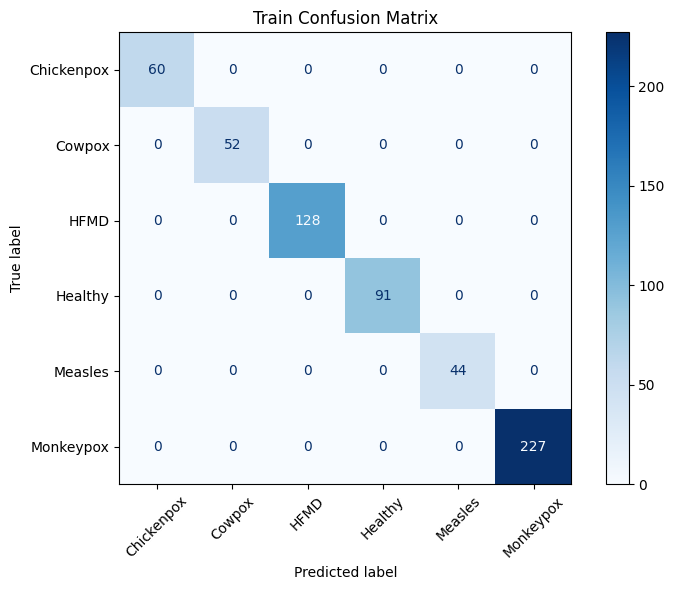

In [15]:
train_metrics = evaluate_model(
    model=model,
    loader=train_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=train_metrics,
    class_names=CLASS_NAMES,
    split_name="Train"
)

plot_confusion_matrix(
    metrics=train_metrics,
    class_names=CLASS_NAMES,
    split_name="Train",
    save_path=SAVE_DIR / "train_confusion_matrix.png"
)


===== VALIDATION METRICS =====
Accuracy     : 0.8082
Precision    : 0.8175
Recall       : 0.7689
F1-score     : 0.7834
ROC-AUC      : 0.9561
Sensitivity  : 0.7689
Specificity  : 0.9565
MCC          : 0.7480

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.7143    0.7143    0.7143         7
      Cowpox     0.5714    0.6667    0.6154         6
        HFMD     0.8333    0.9375    0.8824        16
     Healthy     1.0000    0.9091    0.9524        11
     Measles     1.0000    0.6000    0.7500         5
   Monkeypox     0.7857    0.7857    0.7857        28

    accuracy                         0.8082        73
   macro avg     0.8175    0.7689    0.7834        73
weighted avg     0.8187    0.8082    0.8087        73

Saved confusion matrix: experiments/vgg16_optimizer_search/validation_confusion_matrix.png


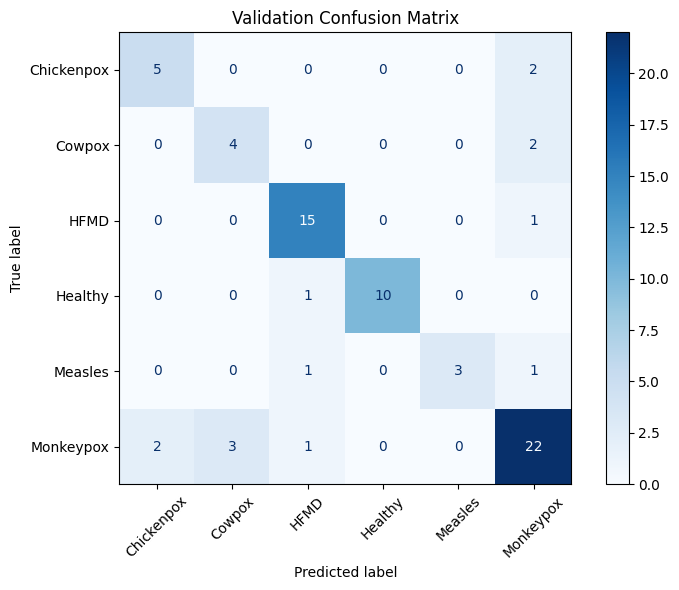

In [16]:
val_metrics = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=val_metrics,
    class_names=CLASS_NAMES,
    split_name="Validation"
)

plot_confusion_matrix(
    metrics=val_metrics,
    class_names=CLASS_NAMES,
    split_name="Validation",
    save_path=SAVE_DIR / "validation_confusion_matrix.png"
)


===== TEST METRICS =====
Accuracy     : 0.8500
Precision    : 0.8679
Recall       : 0.8091
F1-score     : 0.8265
ROC-AUC      : 0.9810
Sensitivity  : 0.8091
Specificity  : 0.9659
MCC          : 0.8071

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.7000    0.8750    0.7778         8
      Cowpox     1.0000    0.7500    0.8571         8
        HFMD     0.8947    1.0000    0.9444        17
     Healthy     1.0000    0.6667    0.8000        12
     Measles     0.8000    0.6667    0.7273         6
   Monkeypox     0.8125    0.8966    0.8525        29

    accuracy                         0.8500        80
   macro avg     0.8679    0.8091    0.8265        80
weighted avg     0.8647    0.8500    0.8477        80

Saved confusion matrix: experiments/vgg16_optimizer_search/test_confusion_matrix.png


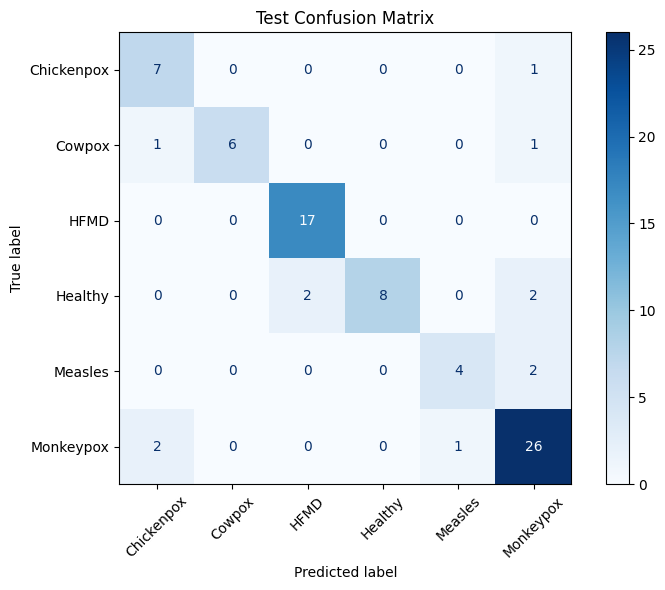

In [17]:
test_metrics = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=test_metrics,
    class_names=CLASS_NAMES,
    split_name="Test"
)

plot_confusion_matrix(
    metrics=test_metrics,
    class_names=CLASS_NAMES,
    split_name="Test",
    save_path=SAVE_DIR / "test_confusion_matrix.png"
)

In [18]:
import matplotlib.pyplot as plt
import torch
import random

# =========================
# COLLECT CORRECT / WRONG SAMPLES
# =========================

def unnormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)

    return img.permute(1, 2, 0).numpy()


def collect_prediction_samples(model, loader, dataset, device):
    model.eval()

    correct_samples = []
    wrong_samples = []

    sample_idx = 0

    with torch.no_grad():
        for images, labels in loader:
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            for i in range(images.size(0)):
                img_path = dataset.samples[sample_idx][0]

                item = {
                    "image": images[i],
                    "path": img_path,
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].cpu().item(),
                    "confidence": probs[i][preds[i]].cpu().item()
                }

                if item["true_label"] == item["pred_label"]:
                    correct_samples.append(item)
                else:
                    wrong_samples.append(item)

                sample_idx += 1

    return correct_samples, wrong_samples


correct_samples, wrong_samples = collect_prediction_samples(
    model=model,
    loader=test_loader,
    dataset=test_dataset,
    device=DEVICE
)

print("Correct samples:", len(correct_samples))
print("Wrong samples:", len(wrong_samples))

Correct samples: 68
Wrong samples: 12


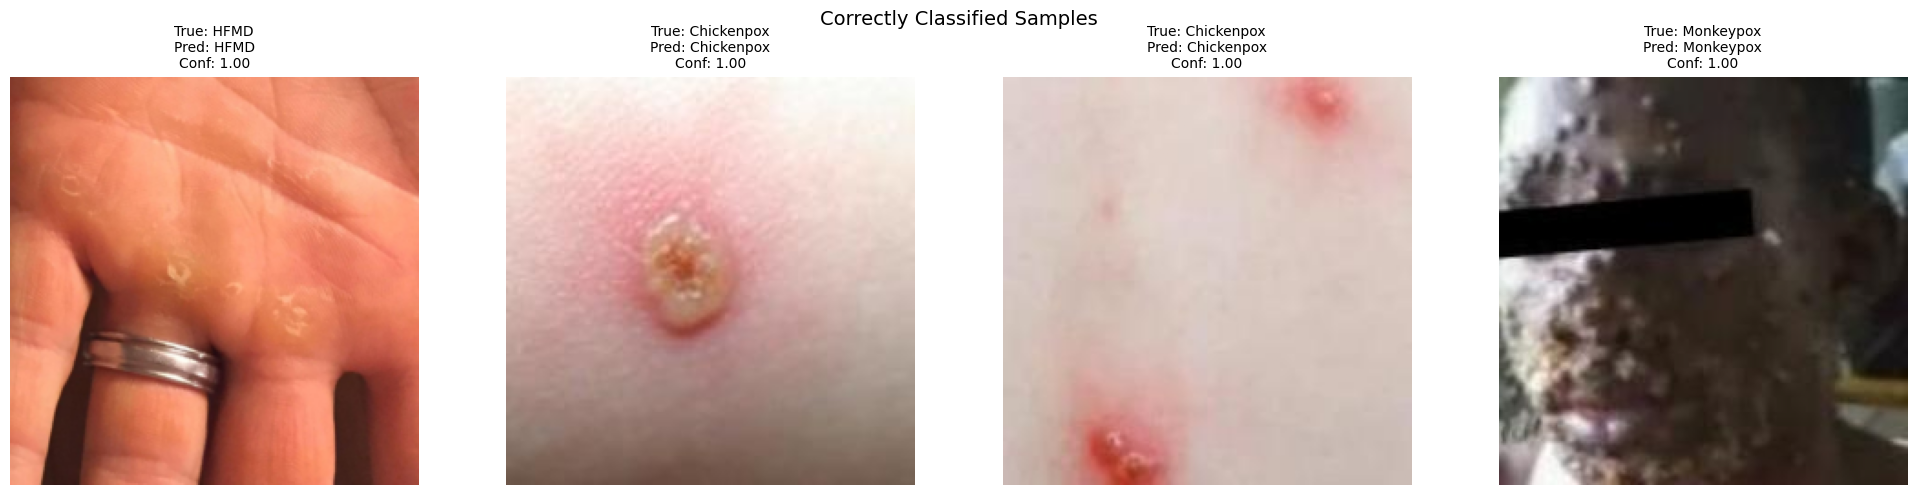

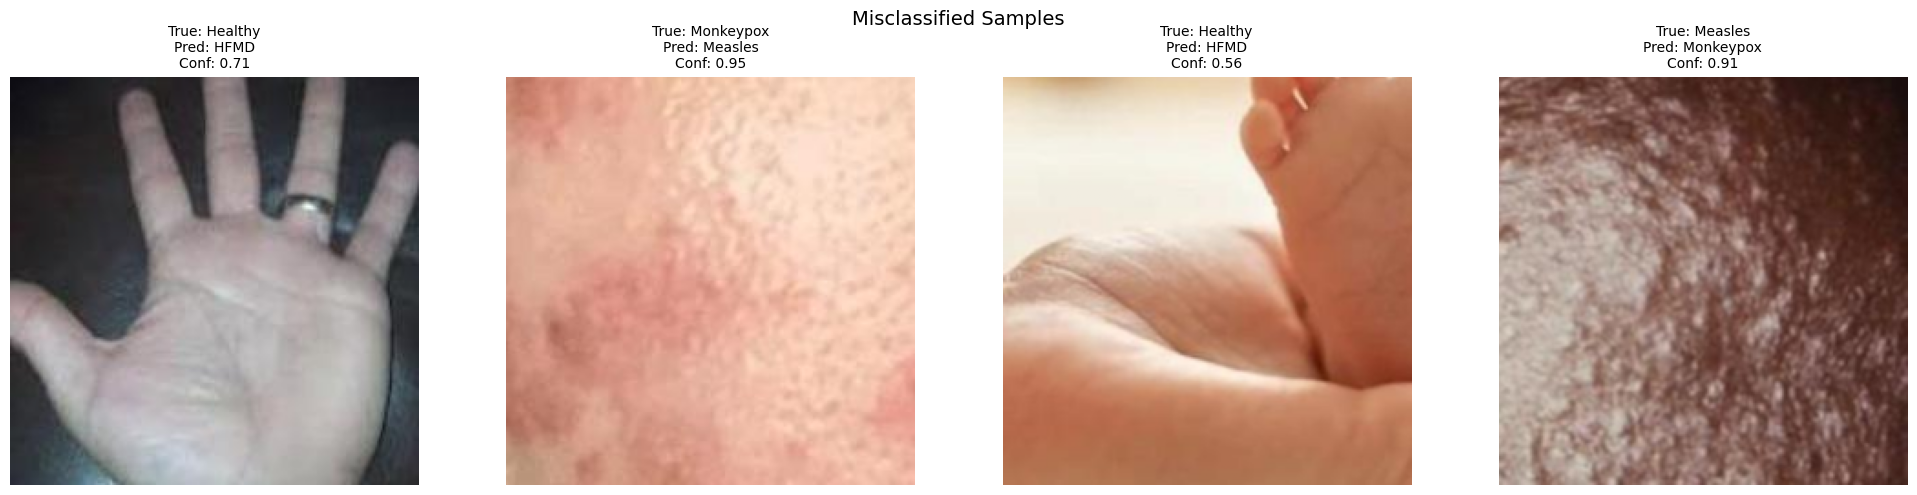

In [19]:
# =========================
# SHOW 3 CORRECT + 3 WRONG
# =========================

def show_samples(samples, class_names, title, n=3):
    n = min(n, len(samples))

    selected = random.sample(samples, n)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    for ax, item in zip(axes, selected):
        img = unnormalize_img(item["image"])

        true_name = class_names[item["true_label"]]
        pred_name = class_names[item["pred_label"]]
        conf = item["confidence"]

        ax.imshow(img)
        ax.set_title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}",
            fontsize=10
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_samples(
    samples=correct_samples,
    class_names=CLASS_NAMES,
    title="Correctly Classified Samples",
    n=4
)

show_samples(
    samples=wrong_samples,
    class_names=CLASS_NAMES,
    title="Misclassified Samples",
    n=4
)

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Nếu đang có history_rows
history_df = pd.DataFrame(history_rows)

# Nếu đang có history_df rồi thì bỏ dòng trên

history_path = SAVE_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
display(history_df.head())

Saved: experiments/vgg16_optimizer_search/training_history.csv


,experiment_id,optimizer,epoch,current_lr,train_loss,train_acc,val_loss,val_acc,val_f1
0,3,SGD,1,0.0001,1.891520,0.122924,1.732629,0.205479,0.111993
1,3,SGD,2,0.0001,1.720266,0.292359,1.563235,0.397260,0.134203
2,3,SGD,3,0.0001,1.576636,0.397010,1.440768,0.452055,0.180712
3,3,SGD,4,0.0001,1.472201,0.438538,1.354965,0.493151,0.246137
4,3,SGD,5,0.0001,1.428383,0.488372,1.280422,0.547945,0.300051


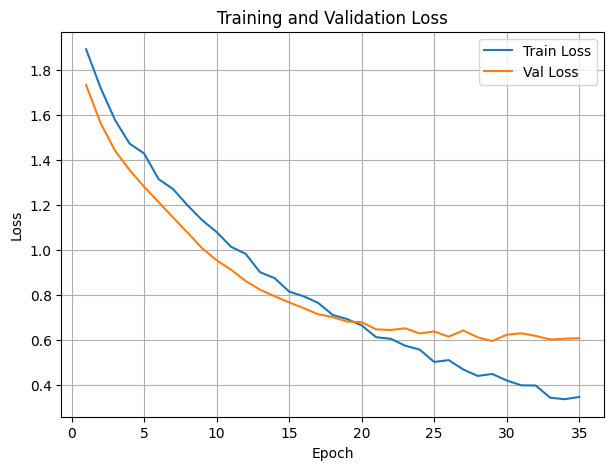

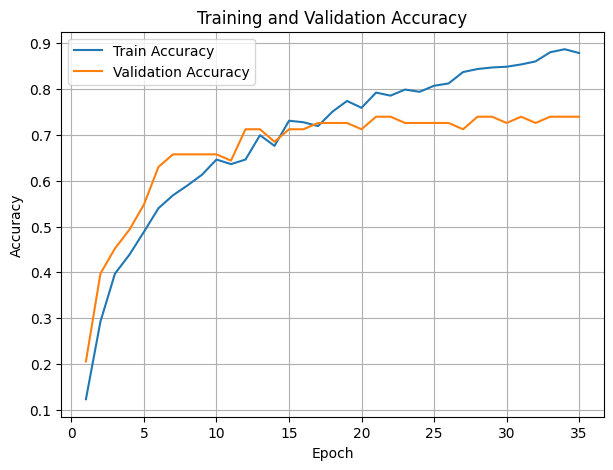

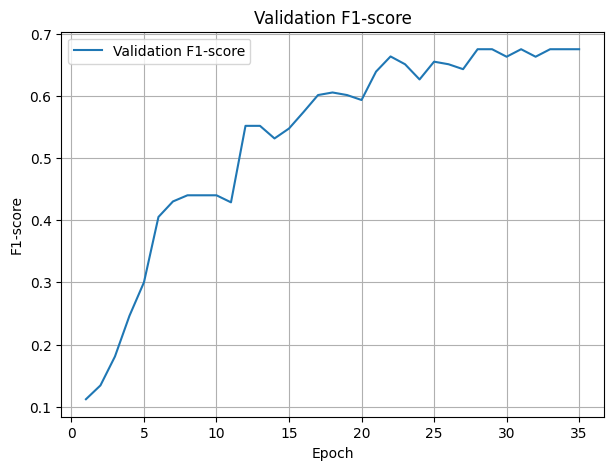

In [21]:
# =========================
# PLOT TRAINING CURVES
# =========================

plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], label="Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Validation F1-score")
plt.legend()
plt.grid(True)
plt.show()